## Direct Sampling Tutorial

### Load tissue sample

(4, 8)


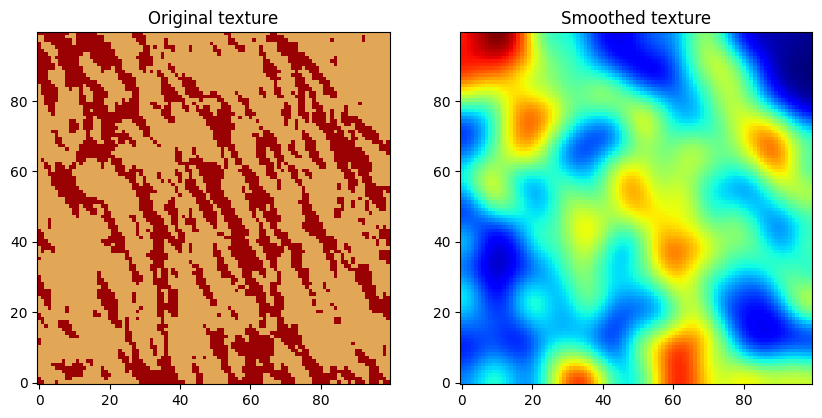

In [1]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import bitis as bt

from matplotlib import colors as mcolors

tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, 'white'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

df = bt.tissue_dataset()

# Filter the dataset to extract one specific texture that meets the criteria:
filtered_df = df[(df['Density'].between(0.3, 0.35)) &
                 (df['Elongation'] > 2.5)]

print(filtered_df.shape)
texture = filtered_df["Tissue Matrix"].iloc[1]

# 1 - healthy tissue, 2 - fibrosis
texture = np.where(texture == 0, 1, 2).astype(np.float32)

texture_smoothed = gaussian_filter(texture, sigma=5)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(texture, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
axs[0].set_title('Original texture')
axs[1].imshow(texture_smoothed, cmap='jet', origin='lower')
axs[1].set_title('Smoothed texture')
plt.show()

**Show available samples**

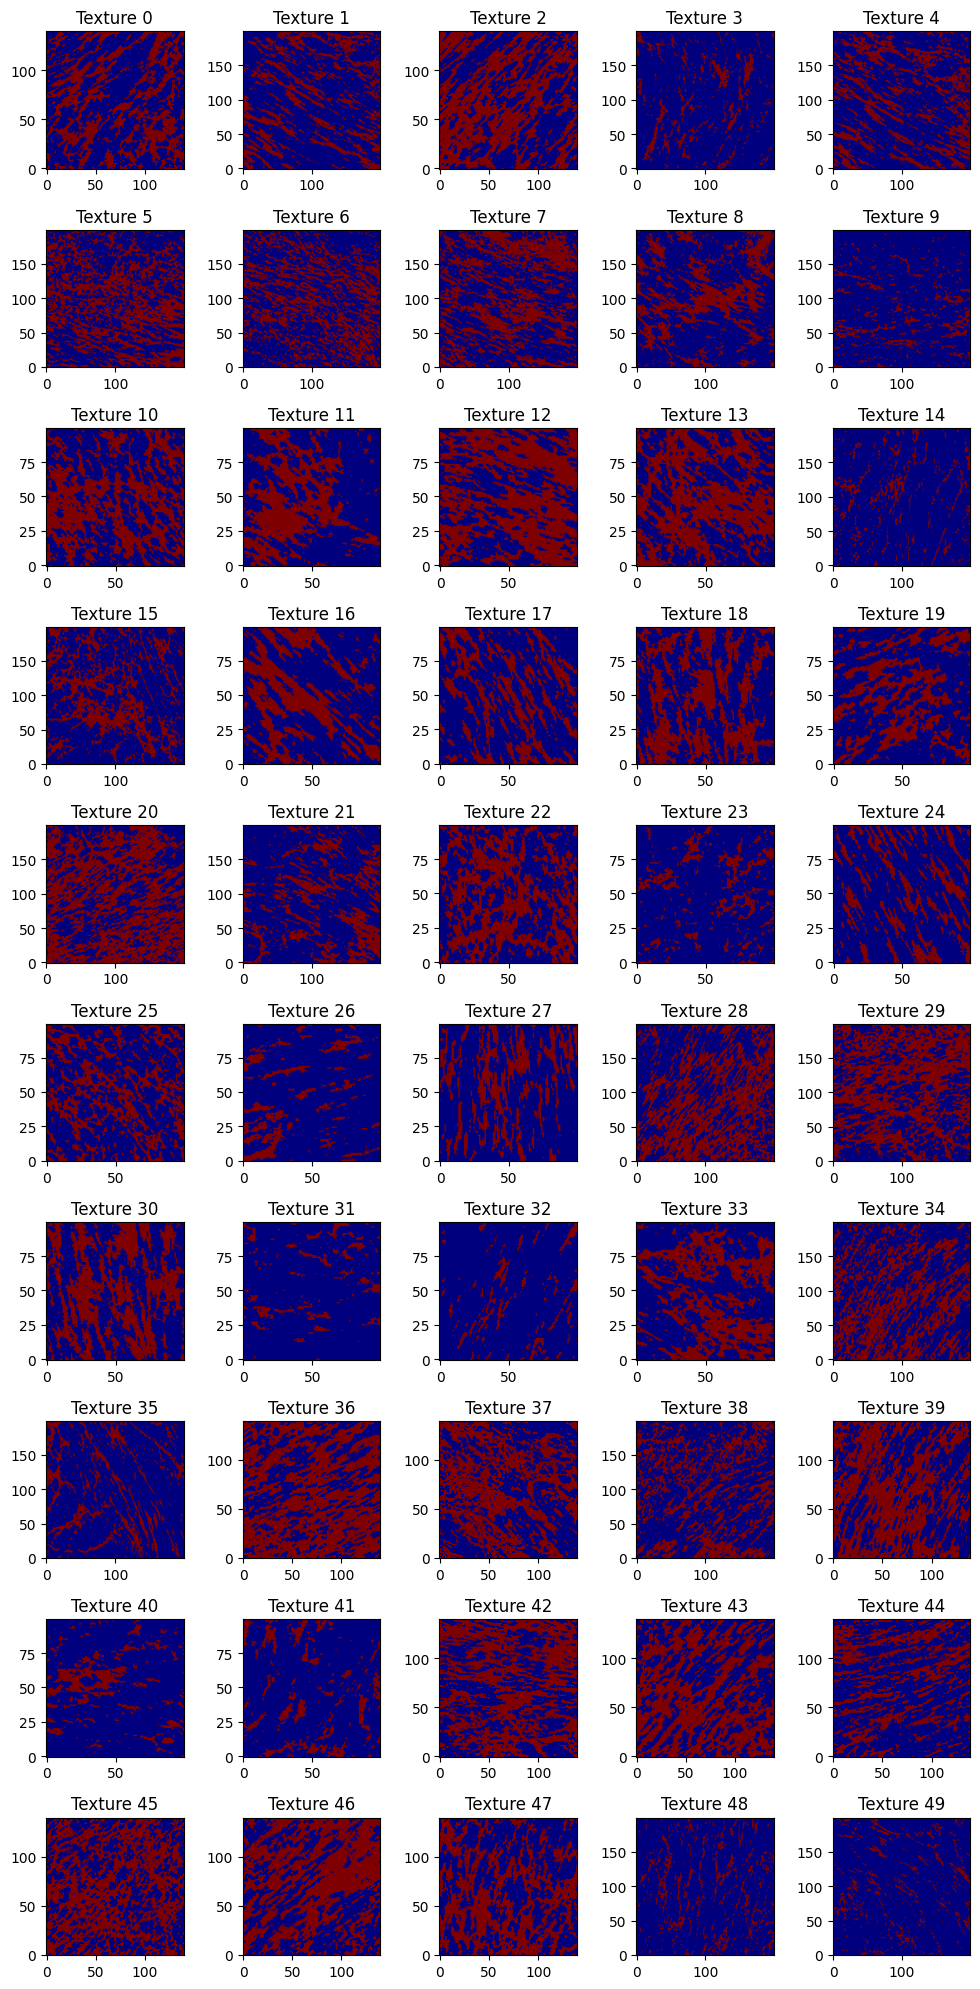

In [162]:
fig, axs = plt.subplots(nrows=10, ncols=5, figsize=(10, 20))
for i in range(50):
    ax = axs.flat[i]
    im = df["Tissue Matrix"].iloc[i]
    im = np.where(im == 0, 1, 2).astype(np.float32)
    ax.imshow(im, cmap='jet', origin='lower')
    ax.set_title(f"Texture {i}")
plt.tight_layout()
plt.show()


### Direct Sampling with fixed template size

100%|██████████| 40000/40000 [01:05<00:00, 608.54it/s]


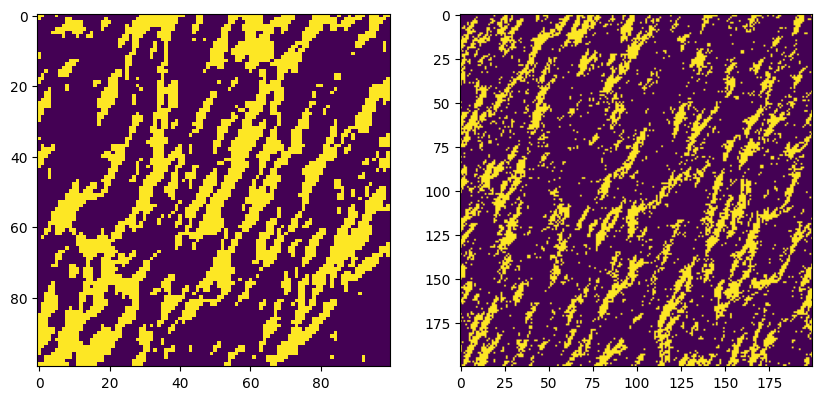

In [5]:
training_images = [texture.copy().astype(float)]

simulation_tex = np.zeros((200, 200), dtype=np.float32)

simulation = bt.DirectSampling(simulation_tex, training_images,
                               template_size=15,
                               min_distance=0.01)
ds_texture = simulation.run().copy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(texture)
ax[1].imshow(ds_texture)
plt.show()

100%|██████████| 40000/40000 [00:06<00:00, 6594.11it/s]


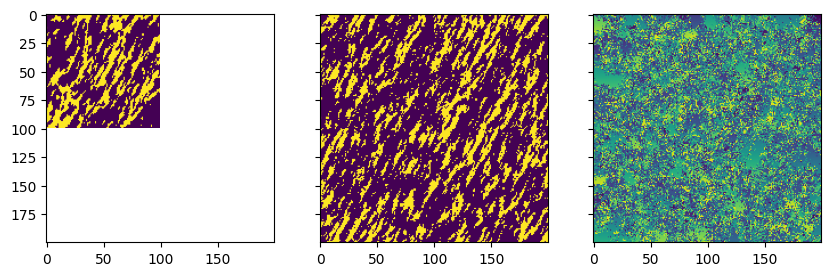

In [6]:
training_tex = texture.copy().astype(float)

simulation_tex = np.zeros((200, 200))
simulation = bt.AdaptiveSampling(simulation_tex,
                                 training_tex,
                                 max_known_pixels=30,
                                 min_known_pixels=5,
                                 max_template_size=50,
                                 min_template_size=5,
                                 n_candidates=1)

adaptive_tex = simulation.run().copy()

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(training_tex)
ax[1].imshow(adaptive_tex)
ax[2].imshow(simulation._index_map)
plt.show()

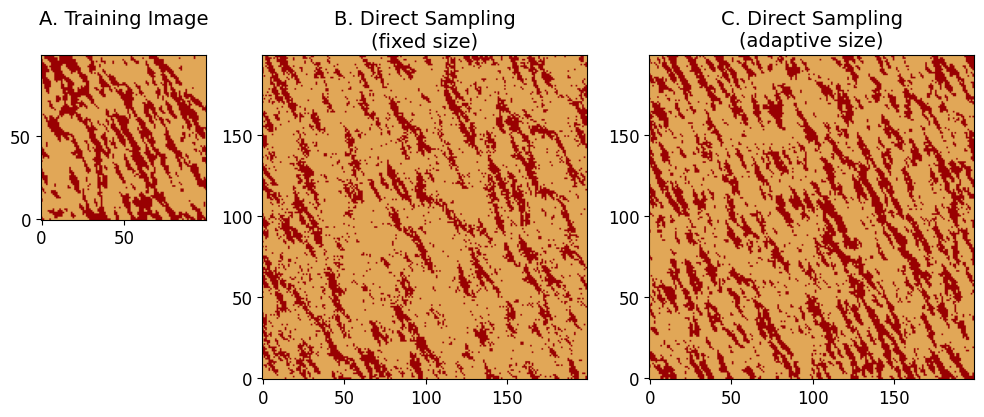

In [11]:
from skimage import morphology


mask = morphology.remove_small_objects(ds_texture == 2, min_size=1, connectivity=1)
ds_filtered = np.zeros_like(ds_texture)
ds_filtered[mask] = 2
ds_filtered[~mask] = 1

fig, axs = plt.subplots(ncols=3, figsize=(10, 4), width_ratios=[1, 2, 2])


axs[0].set_title('A. Training Image\n', fontsize=14)
axs[1].set_title('B. Direct Sampling\n(fixed size)', fontsize=14)
axs[2].set_title('C. Direct Sampling\n(adaptive size)', fontsize=14)

axs[0].set_xticks(np.arange(0, 101, 50))
axs[1].set_xticks(np.arange(0, 201, 50))
axs[2].set_xticks(np.arange(0, 201, 50))

axs[0].set_yticks(np.arange(0, 101, 50))
axs[1].set_yticks(np.arange(0, 201, 50))
axs[2].set_yticks(np.arange(0, 201, 50))

for l in range(3):
    # set ticks font size
    axs[l].tick_params(axis='both', which='major', labelsize=12)

axs[0].imshow(texture, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
axs[1].imshow(ds_filtered, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
axs[2].imshow(adaptive_tex, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)

for ax in axs.flat:
    ax.set_anchor('NW')

plt.tight_layout()
plt.show()

In [12]:
fig.savefig('figure2.png', dpi=300, bbox_inches='tight')

In [13]:
index_maps = [np.arange(0, training_tex.size).reshape(training_tex.shape)]
as_results = [training_tex]

for i in [1, 3, 5]:
    simulation_tex = np.zeros((200, 200))
    simulation = bt.AdaptiveSampling(simulation_tex,
                                    training_tex,
                                    max_known_pixels=30,
                                    min_known_pixels=5,
                                    max_template_size=50,
                                    min_template_size=5,
                                    n_candidates=i)

    adaptive_tex = simulation.run().copy()

    index_maps.append(simulation._index_map.copy())
    as_results.append(adaptive_tex)

100%|██████████| 40000/40000 [00:08<00:00, 4605.66it/s]


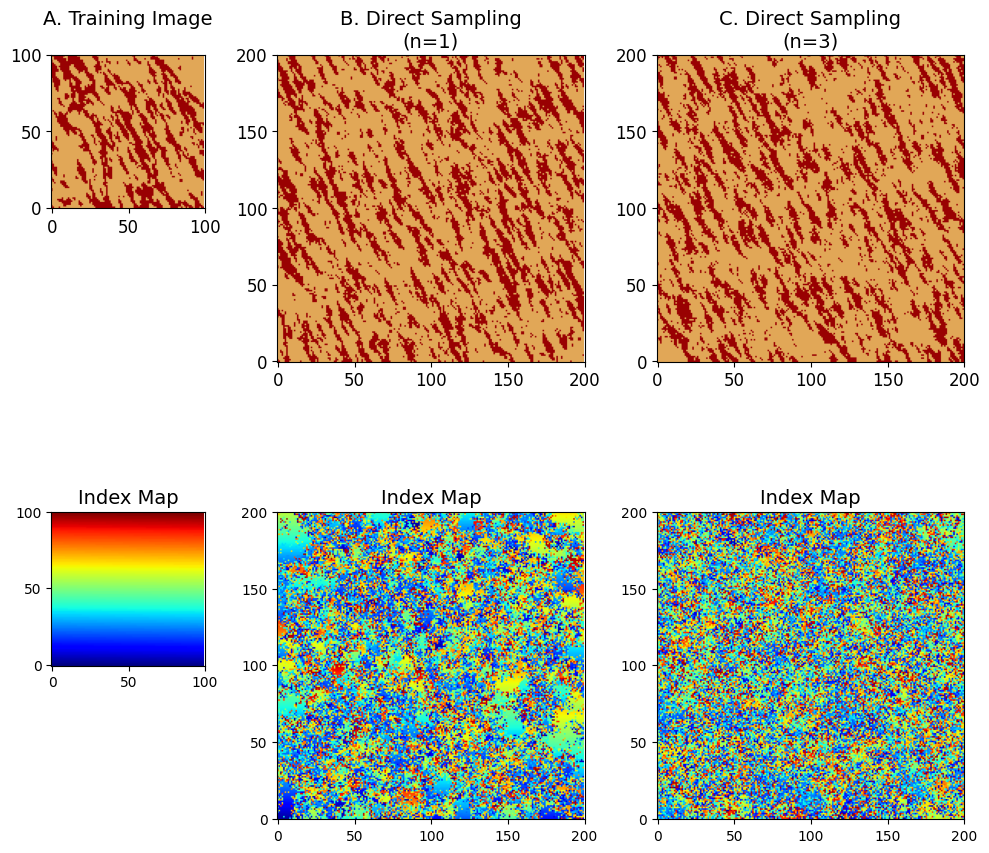

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 8),
                        width_ratios=[1, 2, 2])
for i in range(3):
    ax = axs[0, i]
    ax.imshow(as_results[i], cmap=tex_cmap, origin='lower', vmin=0, vmax=2)

    ax = axs[1, i]
    im = index_maps[i]
    im = im.reshape((im.shape[0], im.shape[1]))
    ax.imshow(im, cmap='jet', origin='lower')
    ax.set_title('Index Map', fontsize=14)

axs[0, 0].set_title('A. Training Image\n', fontsize=14)
axs[0, 1].set_title('B. Direct Sampling\n(n=1)', fontsize=14)
axs[0, 2].set_title('C. Direct Sampling\n(n=3)', fontsize=14)

for i in range(2):
    axs[i, 0].set_xticks(np.arange(0, 101, 50))
    axs[i, 1].set_xticks(np.arange(0, 201, 50))
    axs[i, 2].set_xticks(np.arange(0, 201, 50))
    axs[i, 0].set_yticks(np.arange(0, 101, 50))
    axs[i, 1].set_yticks(np.arange(0, 201, 50))
    axs[i, 2].set_yticks(np.arange(0, 201, 50))

for l in range(3):
    # set ticks font size
    ax = axs.flat[l]
    ax.tick_params(axis='both', which='major', labelsize=12)

for ax in axs.flat:
    ax.set_anchor('NW')

plt.tight_layout()
plt.show()

In [17]:
fig.savefig('figure3.png', dpi=300, bbox_inches='tight')

### Conditioning as density parametrization

1.0 0.0


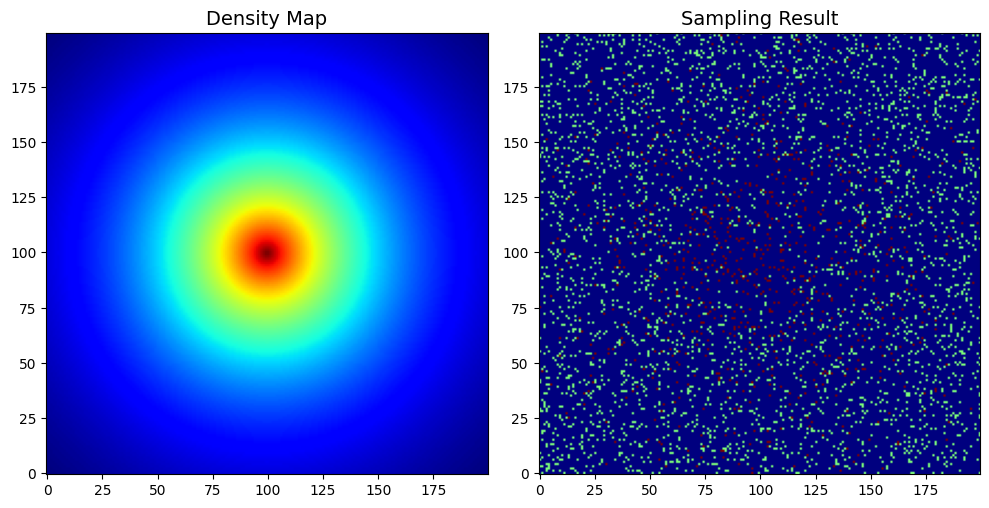

In [ ]:
# generate 2d distribution with decaying density from center
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)
Z = np.exp(-2 * np.sqrt(X**2 + Y**2))

Z = (Z - Z.min()) / (Z.max() - Z.min())  # Normalize to [0, 0.5]
# Z[Z > 0.5] = 0.5  # Cap the maximum value to 0.5
print(Z.max(), Z.min())

R = np.random.random((200, 200))
R = np.where(R < Z, 2, 1)  # Apply the dec
R2 = np.random.random((200, 200))
R[R2 > 0.1] = 0

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axs[0].imshow(Z, cmap='jet', origin='lower')
axs[0].set_title('Density Map', fontsize=14)
axs[1].imshow(R, cmap='jet', origin='lower')
axs[1].set_title('Sampling Result', fontsize=14)
plt.tight_layout()
plt.show()

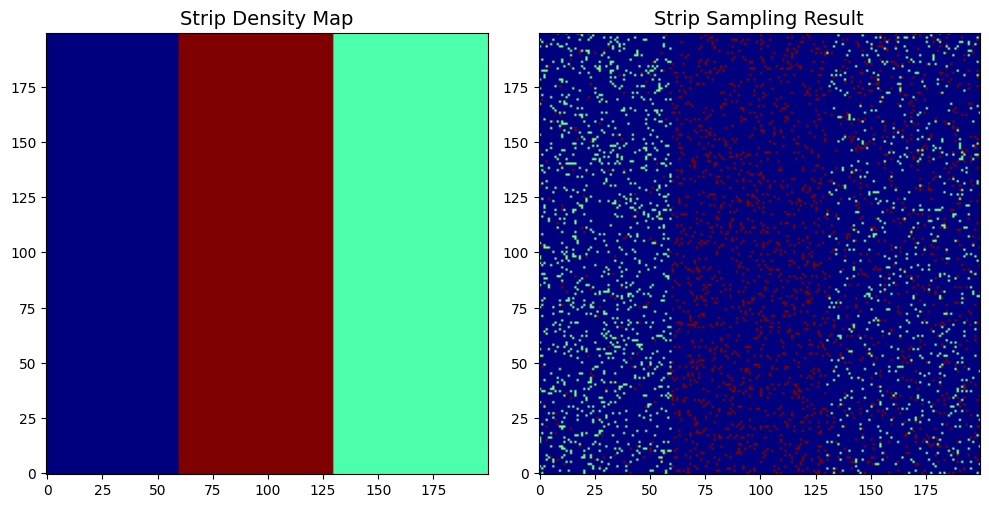

In [156]:
strip_map = np.zeros((200, 200))
strip_map[:, :60] = 0.1
strip_map[:, 60:130] = 1.
strip_map[:, 130:] = 0.5

R3 = np.random.random((200, 200))
R3 = np.where(R3 < strip_map, 2, 1)
R4 = np.random.random((200, 200))
R3[R4 > 0.1] = 0

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axs[0].imshow(strip_map, cmap='jet', origin='lower')
axs[0].set_title('Strip Density Map', fontsize=14)
axs[1].imshow(R3, cmap='jet', origin='lower')
axs[1].set_title('Strip Sampling Result', fontsize=14)
plt.tight_layout()
plt.show()

100%|██████████| 35957/35957 [00:04<00:00, 7878.46it/s]


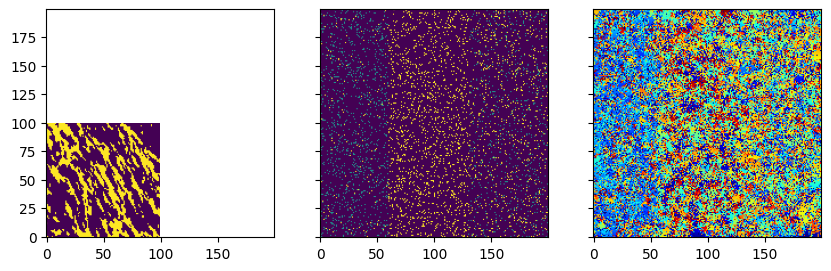

In [157]:
texture = df["Tissue Matrix"].iloc[17]
training_tex = np.where(texture == 0, 1, 2).astype(np.float32)

condition_texs = [R, R3]
density_maps = [Z, strip_map]
condition_res = []

for condition_tex in condition_texs:
    simulation_tex = condition_tex.copy()
    simulation = bt.AdaptiveSampling(simulation_tex,
                                    training_tex,
                                    max_known_pixels=30,
                                    min_known_pixels=5,
                                    max_template_size=50,
                                    min_template_size=5,
                                    n_candidates=1)

    simulated_tex = simulation.run().copy()
    condition_res.append(simulated_tex)

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(training_tex)
ax[1].imshow(condition_tex)
ax[2].imshow(simulation._index_map, cmap='jet', origin='lower')
plt.show()

In [136]:
print(simulated_tex[:, :60].mean() - 1)
print(simulated_tex[:, 60:140].mean() - 1)
print(simulated_tex[:, 130:].mean() - 1)

0.1728333333333334
0.41537500000000005
0.2589285714285714


In [131]:
print(texture.mean())

0.3302


NameError: name 'condition_res' is not defined

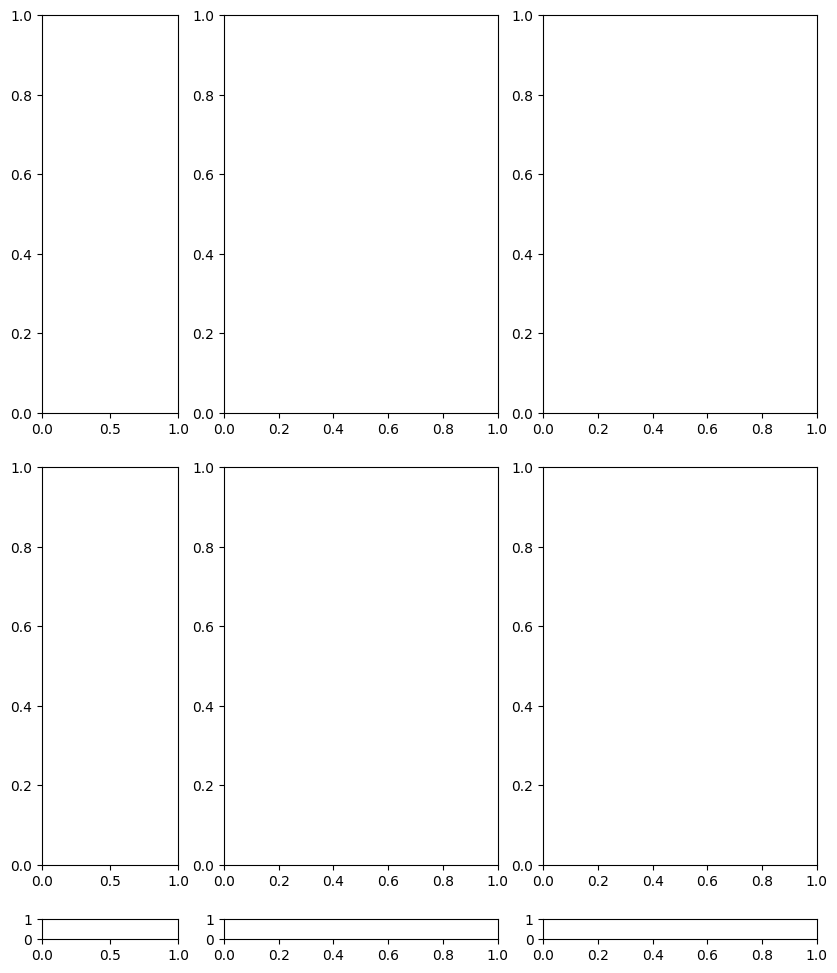

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 8.5),
                        width_ratios=[1, 2, 2],
                        height_ratios=[1, 1, 0.05])
for i in range(1, 3):
    ax = axs[0, i]
    ax.imshow(condition_res[i-1], cmap=tex_cmap, origin='lower',
              vmin=0, vmax=2)

    ax = axs[1, i]
    im = density_maps[i-1]
    im = im.reshape((im.shape[0], im.shape[1]))
    ax.imshow(im, cmap='jet', origin='lower', vmin=0, vmax=1)
    ax.set_title('Density Map', fontsize=14)
    # add colorbar for ax[1, i]
    cbar = plt.colorbar(ax.images[0], cax=axs[2, i], orientation='horizontal')

axs[0, 0].imshow(training_tex, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
axs[1, 0].axis('off')  # Hide the first subplot in the second row
axs[2, 0].axis('off')  # Hide the colorbar for the first column

axs[0, 0].set_title('A. Training Image', fontsize=14)
axs[0, 1].set_title('B. Radial gradient', fontsize=14)
axs[0, 2].set_title('C. Three-zone', fontsize=14)

for i in range(2):
    axs[i, 0].set_xticks(np.arange(0, 101, 50))
    axs[i, 1].set_xticks(np.arange(0, 201, 50))
    axs[i, 2].set_xticks(np.arange(0, 201, 50))
    axs[i, 0].set_yticks(np.arange(0, 101, 50))
    axs[i, 1].set_yticks(np.arange(0, 201, 50))
    axs[i, 2].set_yticks(np.arange(0, 201, 50))

for l in range(3):
    # set ticks font size
    ax = axs.flat[l]
    ax.tick_params(axis='both', which='major', labelsize=12)

for ax in axs.flat:
    ax.set_anchor('NW')

plt.tight_layout()
plt.show()

In [161]:
fig.savefig('figure4.png', dpi=300, bbox_inches='tight')

100%|██████████| 40000/40000 [00:06<00:00, 6445.48it/s]


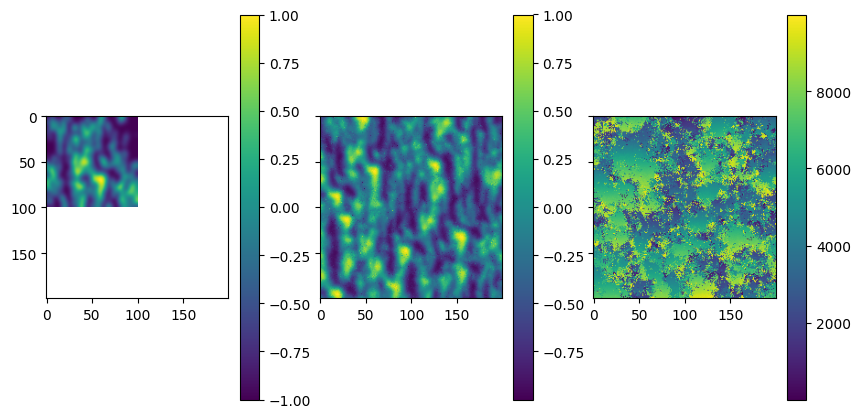

In [42]:
import bitis as bt
from scipy import ndimage

texture = df["Tissue Matrix"].iloc[27]

training_image = ndimage.gaussian_filter(texture.astype(np.float32), sigma=3)
# normalize the training image between -1 and 1
training_image = (training_image - np.min(training_image)) / (np.max(training_image) - np.min(training_image))
training_image = training_image * 2 - 1  # Scale

max_known_pixels = 30
max_template_size = 40
min_template_size = 3
num_of_candidates = 3
min_known_pixels = 5

simulation_tex = np.zeros((200, 200), dtype=np.float32)
simulation = bt.Simulation()
simulation.path_builder = bt.RandomSimulationPathBuilder(simulation_tex)
simulation.template_builder = bt.AdaptiveTemplateBuilder(simulation_tex,
                                                         max_known_pixels,
                                                         max_template_size,
                                                         min_template_size)
simulation.template_matching = bt.ContinuousVariableMatching(training_image,
                                                             num_of_candidates,
                                                             min_known_pixels)
simulated_tex = simulation.run()
joint_simulated_image = simulated_tex.copy()
joint_training_image = training_image.copy()

%matplotlib inline

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
fig.colorbar(ax[0].imshow(joint_training_image))
fig.colorbar(ax[1].imshow(joint_simulated_image))
fig.colorbar(ax[2].imshow(simulation._index_map))
plt.show()


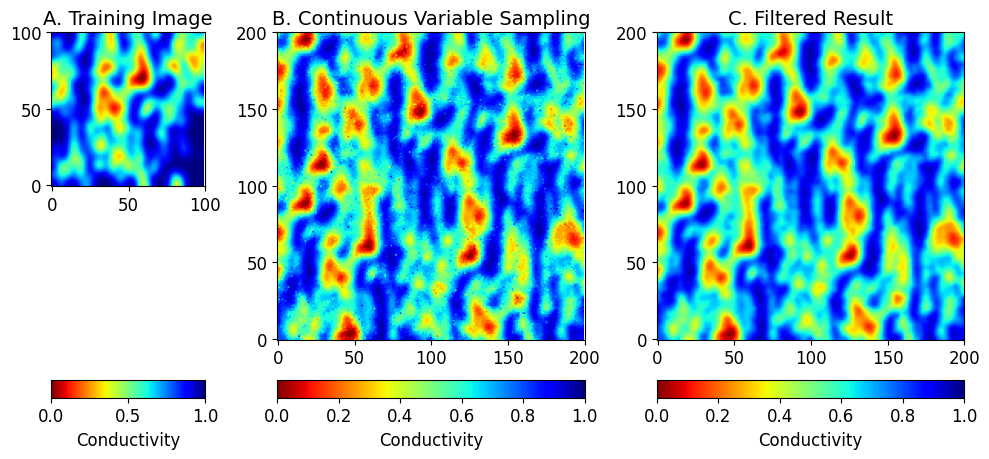

In [44]:
filtered_joint_simulated_image = ndimage.gaussian_filter(joint_simulated_image, sigma=1)

def rescale_image(image, min_val=-1, max_val=1):
    """Rescale image to [0, 0.5]"""
    image = (image - min_val) / (max_val - min_val)  # Normalize to [0, 1]
    return image


fig, axs = plt.subplots(2, 3, figsize=(10, 4.7),
                        width_ratios=[1, 2, 2],
                        height_ratios=[1, 0.05])
axs[0, 0].imshow(1 - 1 * rescale_image(joint_training_image),
                 cmap='jet_r', origin='lower', vmin=0, vmax=1)
axs[0, 1].imshow(1 - 1 * rescale_image(joint_simulated_image),
                 cmap='jet_r', origin='lower', vmin=0, vmax=1)
axs[0, 2].imshow(1 - 1 * rescale_image(filtered_joint_simulated_image),
                 cmap='jet_r', origin='lower', vmin=0, vmax=1)

axs[0, 0].set_title('A. Training Image', fontsize=14)
axs[0, 1].set_title('B. Continuous Variable Sampling', fontsize=14)
axs[0, 2].set_title('C. Filtered Result', fontsize=14)

axs[0, 0].set_xticks(np.arange(0, 101, 50))
axs[0, 1].set_xticks(np.arange(0, 201, 50))
axs[0, 2].set_xticks(np.arange(0, 201, 50))
axs[0, 0].set_yticks(np.arange(0, 101, 50))
axs[0, 1].set_yticks(np.arange(0, 201, 50))
axs[0, 2].set_yticks(np.arange(0, 201, 50))

for l in range(3):
    cbar =plt.colorbar(axs[0, l].images[0],
                    cax=axs[1, l],
                    orientation='horizontal',
                    label='Conductivity')

    ticklabs = cbar.ax.get_yticklabels()
    cbar.ax.set_yticklabels(ticklabs, fontsize=10)
    cbar.set_label('Conductivity', fontsize=12)

for ax in axs.flat:
    ax.set_anchor('NW')
    ax.tick_params(axis='both', which='major', labelsize=12)


plt.tight_layout()

plt.show()

In [45]:
fig.savefig('figure5.png', dpi=300, bbox_inches='tight')

100%|██████████| 40000/40000 [00:04<00:00, 9169.74it/s]


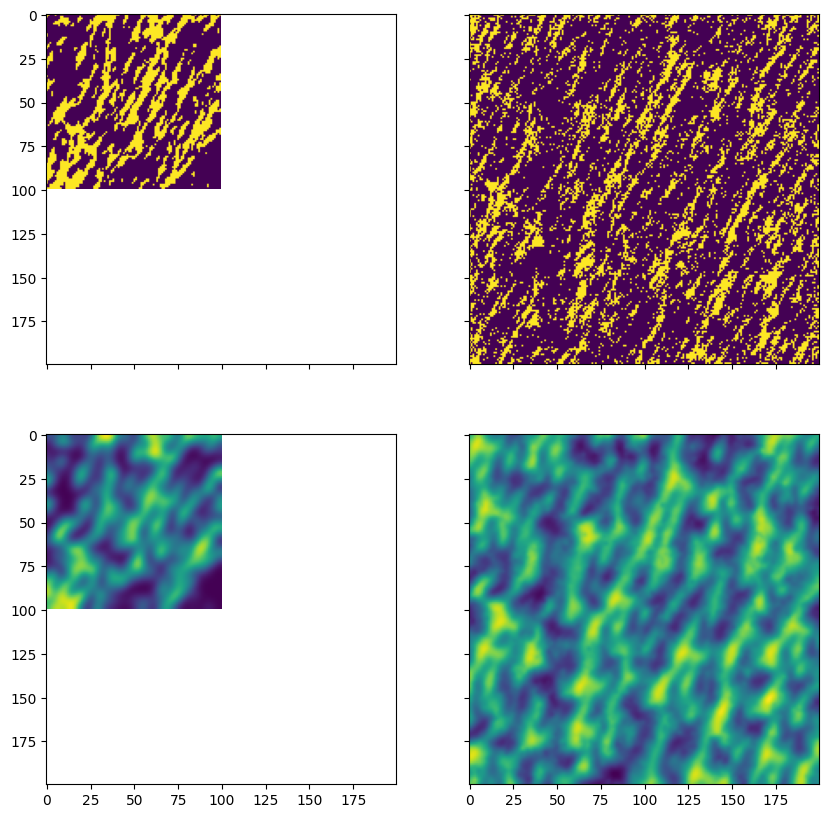

In [ ]:
import bitis as bt


training_image = texture.copy()

max_known_pixels = 30
max_template_size = 40
min_template_size = 3
num_of_candidates = 1
min_known_pixels = 1

simulation_tex = np.zeros_like(filtered_joint_simulated_image)
multi_var_simulation = bt.Simulation()
multi_var_simulation.path_builder = bt.MultivariateSimulationPathBuilder(simulation_tex)
multi_var_simulation.template_builder = bt.AdaptiveTemplateBuilder(simulation_tex,
                                                         max_known_pixels,
                                                         max_template_size,
                                                         min_template_size)
multi_var_simulation.template_matching = bt.MultivariateVariableMatching(training_image,
                                                               joint_training_image,
                                                               filtered_joint_simulated_image,
                                                               num_of_candidates,
                                                               min_known_pixels)

simulated_tex = multi_var_simulation.run()

%matplotlib inline

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10),
                       sharex=True, sharey=True)
ax[0, 0].imshow(training_image)
ax[0, 1].imshow(simulated_tex)
ax[1, 0].imshow(joint_training_image)
ax[1, 1].imshow(filtered_joint_simulated_image)
plt.show()

In [ ]:
%matplotlib qt

fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(10, 7),
                       sharex=True, sharey=True)
ax[0, 0].imshow(training_image, origin='lower', cmap='jet')
ax[0, 1].imshow(simulated_tex, origin='lower', cmap='jet')
ax[1, 0].imshow(joint_training_image, origin='lower', cmap='jet')
ax[1, 1].imshow(joint_simulated_image, origin='lower', cmap='jet')
ax[0, 2].imshow(multi_var_simulation._index_map, origin='lower', cmap='jet')
ax[1, 2].imshow(multi_var_simulation.path_builder.joint_image, origin='lower', cmap='jet')
plt.show()

2025-03-14 22:04:59.932 python[5095:145397] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-14 22:04:59.932 python[5095:145397] +[IMKInputSession subclass]: chose IMKInputSession_Modern
